# Generate data for comparison between models

In [1]:
import numpy as np
from scipy.interpolate import LinearNDInterpolator
import os
import re

## 1D LID model

This model solves 1D D transport problem with a varying heat load.

The code block below can be used to preform scan over the whole range of parameters.

In [ ]:
from LID_1D import run_1D

durations = ["1ms"]
max_energies = [1.003, 0.351]
rs = np.linspace(0, 1.5e-3, 62, endpoint=True)
output_folder = f"./LID_1D_results/"

for i, duration in enumerate(durations):
    for j in range(0, 1):

        E0 = max_energies[i] * j / 20

        fluxes = np.zeros_like(rs, dtype=np.float64)
        rets_fin = np.zeros_like(rs, dtype=np.float64)

        for k, r in enumerate(rs):

            data = run_1D(E0, r, duration, output_folder)

            flux = -np.array(data[0].data)
            t = np.array(data.t)

            fluxes[k] = np.trapz(flux, x=t)
            retention = np.array(data[1].data)

            rets_fin[k] = retention[-1]

        des = np.trapz(2 * np.pi * rs * fluxes, x=rs)

        export = np.column_stack([rs.transpose(), rets_fin.transpose()])
        header = f"E={E0:.3f},Desorbed={des}"

        np.savetxt(
            output_folder + f"profiles_{duration}_E{E0:.3f}.txt",
            export,
            header=header,
            delimiter=",",
            comments="",
        )

## 1DD2DT model

This model solves 2D heat equation. Then performs a series of 1D D transport simulations along the radial direction.

**NOTE:** A mesh is required to run the script below. Navigate to "mesh_T2D" folder and run scripts to generate and convert mesh.

In [ ]:
from LID_1DD2DT import run_T2D, run_1DD2DT
from scipy.interpolate import interp1d

durations = ["1ms", "250us"]
max_energies = [1.003, 0.351]
rs = np.linspace(0, 1.5e-3, 50, endpoint=True)
output_folder = f"./LID_1DD2DT_results/"

for i, duration in enumerate(durations):
    for j in range(0, 21):

        E0 = max_energies[i] * j / 20

        run_T2D(E0, rs, duration, output_folder)
        T_surf = np.loadtxt(
            output_folder + f"T_{duration}/Trz_E{E0:.3f}.csv", skiprows=1, delimiter=","
        )

        fluxes = np.zeros_like(rs, dtype=np.float64)
        rets_fin = np.zeros_like(rs, dtype=np.float64)

        for k, r in enumerate(rs):

            T_int = interp1d(T_surf[:, 0], T_surf[:, i + 1])

            data = run_1DD2DT(E0, r, duration, output_folder)

            flux = -np.array(data[0].data)
            t = np.array(data.t)

            fluxes[k] = np.trapz(flux, x=t)
            retention = np.array(data[1].data)

            rets_fin[k] = retention[-1]

        des = np.trapz(2 * np.pi * rs * fluxes, x=rs)

        export = np.column_stack([rs.transpose(), rets_fin.transpose()])
        header = f"E={E0:.3f},Desorbed={des}"

        np.savetxt(
            output_folder + f"profiles_{duration}_E{E0:.3f}.txt",
            export,
            header=header,
            delimiter=",",
            comments="",
        )

## 2D model

This model 2D D transport problem.

**NOTE:** A mesh is required to run the script below. Navigate to "mesh_LID2D" folder and run scripts to generate and convert mesh.

In [ ]:
from LID_2D import run_2D

durations = ["1ms", "250us"]
max_energies = [1.003, 0.351]
output_folder = f"./LID_2D_results/"
N = int(20)


for i, duration in enumerate(durations):

    E0 = max_energies[i] * np.linspace(0, 1, N)
    desorbed = np.zeros(N)

    for j in range(0, N + 1):

        data = run_2D(E0[j], duration, output_folder)

        t = np.array(data.t)
        flux = -np.array(data[0].data)

        des = np.trapz(2 * np.pi * rs * fluxes, x=rs)
        desorbed[j] = des

    export = np.column_stack([E0.transpose(), desorbed.transpose()])
    header = f"E(J),Ndes(atoms)"
    np.savetxt(
        output_folder + f"desorbed_{duration}_E{E0:.3f}.txt",
        export,
        header=header,
        delimiter=",",
        comments="",
    )

## Reconstruction of a field from 1D simulations

In [2]:
def get_data(folder, field, duration, energy, index):
    """
    :param folder: folder
    :type folder: str
    :param field: field: "retention" or "T"
    :type field: str
    :param duration: duration of the pulse: "1ms" or "250us"
    :type duration: str
    :param energy: pulse energy
    :type energy: float
    :param index: col index
    :type index: int
    """

    merged_data = None

    for filename in sorted(os.listdir(folder)):

        if filename.startswith(f"{field}_{duration}_E{energy:.3f}"):
            data = np.loadtxt(folder + filename, skiprows=1, delimiter=",")

            floats_list = re.findall(r"[-+]?(?:\d*\.*\d+)", filename)
            r = np.ones(len(data)) * float(floats_list[-2] + "e" + floats_list[-1])

            combined_data = np.column_stack([r, data[:, 0], data[:, index]])

            if merged_data is None:
                merged_data = combined_data
            else:
                merged_data = np.vstack([merged_data, combined_data])

    return merged_data

## Comparison

In [3]:
folders = ["./LID_1D_results/", "./LID_1DD2DT_results/"]
duration = "1ms"
index = 1  # 1 - the peak temperature, 2 - the final time

r_T = np.linspace(0, 1e-3, 500, endpoint=True)
z_T = np.linspace(0, 6e-3 + 1e-6, 500)
T_r, T_z = np.meshgrid(r_T, z_T)  # 2D grid for interpolation

r_ret = np.linspace(0, 1e-3, 500, endpoint=True)
z_ret = np.linspace(0, 1e-6, 500, endpoint=True)
ret_r, ret_z = np.meshgrid(r_ret, z_ret)  # 2D grid for interpolation

T_fields = []
retention_fields = []
for folder in folders:
    T_data = get_data(folder, "T", duration, 1.003, 1)

    interp = LinearNDInterpolator(
        list(zip(T_data[:, 0], T_data[:, 1])),
        T_data[:, -1].transpose(),
    )
    T_fields.append(interp(T_r, T_z))

    ret_data = get_data(folder, "retention", duration, 1.003, 2)

    interp = LinearNDInterpolator(
        list(zip(ret_data[:, 0], ret_data[:, 1])),
        ret_data[:, -1].transpose(),
    )

    retention_fields.append(interp(ret_r, ret_z))

In [4]:
from dolfin import *
import fenics as f
import matplotlib.tri as tri


def read_field_xdmf(folder, field):
    mesh = Mesh()
    with XDMFFile(MPI.comm_world, folder + "mesh/mesh.xdmf") as infile:
        infile.read(mesh)

    V = FunctionSpace(mesh, "CG", 2)
    field_func = f.Function(V, name="retention")
    f.XDMFFile(folder + f"results_1ms_1.003/{field}.xdmf").read_checkpoint(
        field_func, field, -1
    )

    n = mesh.num_vertices()
    d = mesh.geometry().dim()

    # Create the triangulation
    mesh_coordinates = mesh.coordinates().reshape((n, d))
    triangles = np.asarray([cell.entities(0) for cell in cells(mesh)])
    triangulation = tri.Triangulation(
        mesh_coordinates[:, 0] * 1e3, mesh_coordinates[:, 1] * 1e6 - 6e3, triangles
    )
    z = np.asarray([field_func(point) for point in mesh_coordinates])

    return triangulation, z

/home/vvkulagin/anaconda3/envs/LID_validation_env/lib/python3.11/site-packages/dolfin/jit/jit.py:121: RuntimeWarning: mpi4py.MPI.Session size changed, may indicate binary incompatibility. Expected 32 from C header, got 40 from PyObject
  def compile_class(cpp_data, mpi_comm=MPI.comm_world):


In [5]:
mesh, retention_2D = read_field_xdmf(
    "./LID_2D_results/flux_1ms_E1.003_1225432/", "retention"
)
mesh, T_2D = read_field_xdmf("./LID_2D_results/flux_1ms_E1.003_1225431/", "T")

/tmp/ipykernel_32133/2020084663.py:7: RuntimeWarning: mpi4py.MPI.Session size changed, may indicate binary incompatibility. Expected 32 from C header, got 40 from PyObject
  with XDMFFile(MPI.comm_world, folder+"mesh/mesh.xdmf") as infile:


Now we can compare the results of different models

In [6]:
import matplotlib.pyplot as plt

mpl_params = {
    "text.usetex": True,
    "text.latex.preamble": "\n".join(
        [
            r"\usepackage{bm}",
            r"\usepackage{siunitx}",
            r"\sisetup{detect-all}",
        ]
    ),
    "font.family": "sans-serif",
    "font.sans-serif": "Lato",
    "font.size": 20,
    "legend.frameon": False,
    "axes.linewidth": 2,
    "xtick.major.size": 5,
    "xtick.major.width": 2,
    "ytick.major.size": 5,
    "ytick.major.width": 2,
    "xtick.minor.size": 3,
    "xtick.minor.width": 1.5,
    "ytick.minor.size": 3,
    "ytick.minor.width": 1.5,
}

plt.rcParams.update(mpl_params)
mm2inch = 1e-1 / 2.54

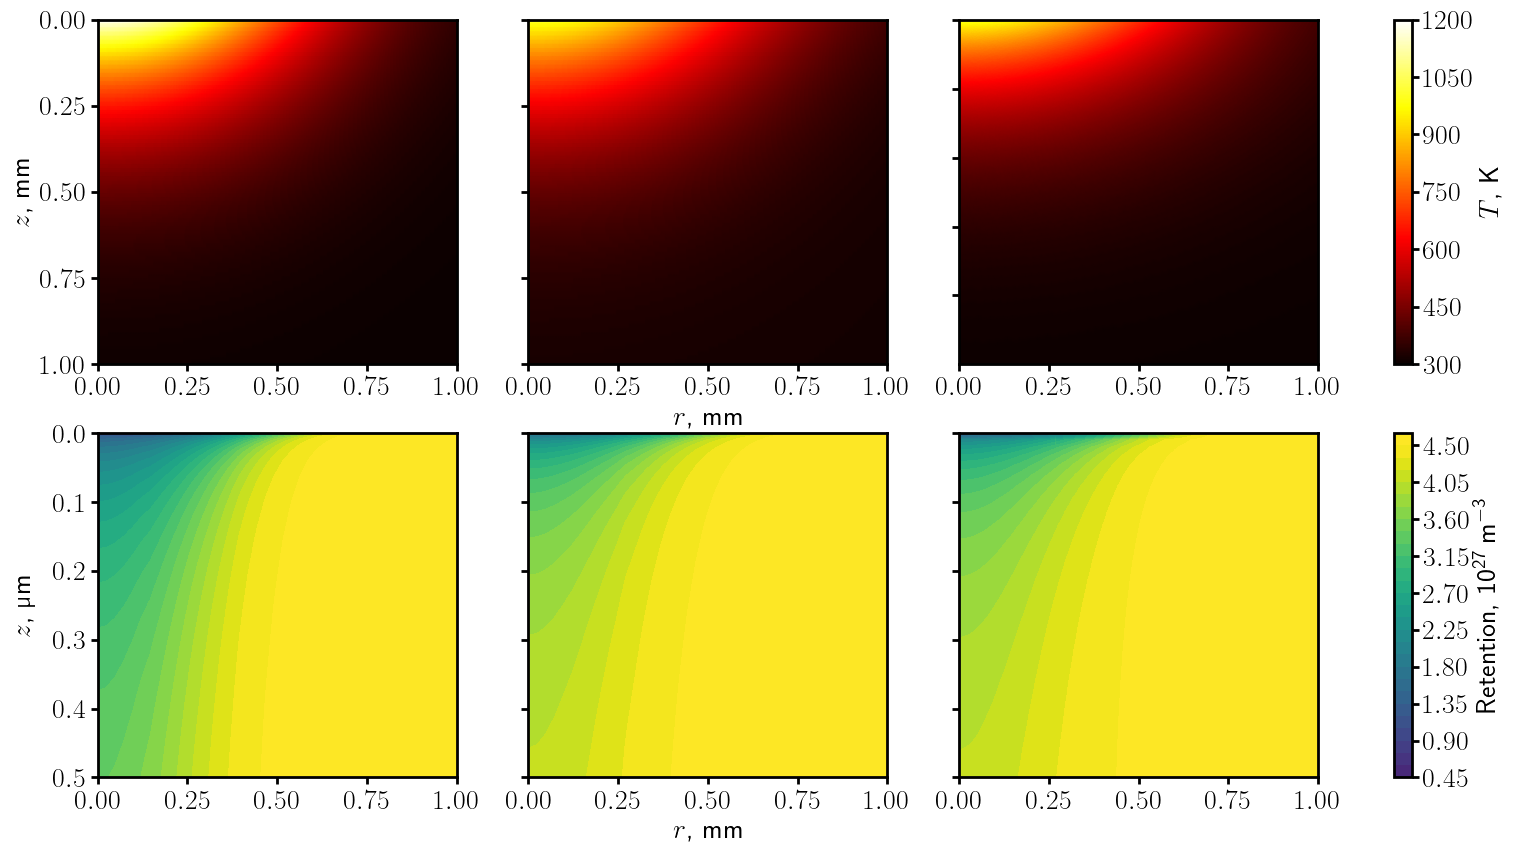

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(500 * mm2inch, 250 * mm2inch))
titles = ["1D", "1DD2DT", "2D"]

for i in range(2):
    pcm = axs[0][i].pcolormesh(
        T_r * 1e3,
        T_z * 1e3,
        T_fields[i],
        shading="gouraud",
        cmap="hot",
        vmin=300,
        vmax=1200,
    )

    pcf = axs[1][i].contourf(
        ret_r * 1e3,
        ret_z * 1e6,
        retention_fields[i] / 1e27,
        cmap="viridis",
        levels=30,
        vmin=0,
        vmax=4.5,
    )

    # axs[0][i].set_title("$T_\mathrm{max}=$"+f"\,{np.max(T_fields[i]):.0f} K")

    axs[0, i].set_ylim(1, 0)

    axs[0, i].set_xticks([0, 0.25, 0.5, 0.75, 1])
    axs[0, i].set_yticks([0, 0.25, 0.5, 0.75, 1])

    axs[1, i].set_ylim(0.5, 0)
    axs[1, i].set_xlim(0, 1)

for i in range(1, 3):
    axs[0][i].tick_params(which="both", labelleft=False)
    axs[1][i].tick_params(which="both", labelleft=False)


axs[0, 0].set_ylabel("$z$, mm")
axs[1, 0].set_ylabel("$z$, $\si{\micro\meter}$")
axs[0, 1].set_xlabel("$r$, mm")
axs[1, 1].set_xlabel("$r$, mm")

axs[0, 2].tripcolor(mesh, T_2D, cmap="hot", shading="gouraud", vmin=300, vmax=1200)
# axs[0,2].set_title("$T_\mathrm{max}=$"+f"\,{np.max(T_2D):.0f} K")
axs[1, 2].tricontourf(mesh, retention_2D / 1e27, levels=30, vmin=0, vmax=4.5)
axs[1, 2].set_xlim(0, 1)
axs[1, 2].set_ylim(0.5, 1.0)
axs[0, 2].set_ylim(1 - 1e3, 1.0)
axs[0, 2].set_xlim(0, 1.0)

fig.colorbar(
    pcm,
    ax=axs[0, :],
    orientation="vertical",
    label="$T$, K",
    ticks=[300, 450, 600, 750, 900, 1050, 1200],
)
fig.colorbar(
    pcf,
    ax=axs[1, :],
    orientation="vertical",
    label="Retention, $\SI{e27}{\meter^{-3}}$",
)

fig.align_ylabels()

# plt.savefig("2D_fields.png", dpi=1000, bbox_inches="tight", pad_inches=0.02)
plt.show()